<font size="10">Projekt ku kurzu Data Science v Pythone</font>

# Netechnické zhrnutie

Cieľom projektu je modelovanie cien bytov na prenájom v USA. Dataset obsahuje približne 10 000 pozorovaní z roku 2019 a podľa štruktúry premennej `source` pravdepodobne vznikol web scrapingom viacerých realitných inzertných portálov.

Použitým prístupom sa podarilo dosiahnuť hodnotu $R^2=76,8\%$ na testovacej množine pre **logaritmus ceny**.

V prípade nelogaritmovanej ceny je $R^2=37,0\%$, avšak po odfiltrovaní 2 % najvyšších hodnôt sa skóre zvýši na $R^2=74,0\%$.

> **Poznámka z vysvetlenia riešenia:** nepoznáme konkrétny business case, preto je zhrnutie zamerané najmä na dataset a dosiahnuté výsledky. V reálnom projekte by tu malo byť jasne uvedené, komu model slúži, ako sa budú predikcie používať a aká chyba je z business pohľadu prijateľná. Rovnako je vhodné zvážiť, či technická metrika ako $R^2$ patrí priamo do manažérskeho zhrnutia.


# Popis datasetu

1. **id** (identifikátor): Unikátny identifikátor inzerátu bytu.
2. **category** (kategória): Kategória inzerátu.
3. **title** (názov): Text názvu inzerátu.
4. **body** (popis): Textový popis bytu.
5. **amenities** (vybavenie): Vybavenie bytu, napr. klimatizácia, basketbalový kôš, káblová televízia, fitness centrum, prístup na internet, bazén, chladnička a pod.
6. **bathrooms** (kúpeľne): Počet kúpeľní.
7. **bedrooms** (spálne): Počet spální.
8. **currency** (mena): Mena inzerátu.
9. **fee** (poplatok): Prípadný dodatočný poplatok.
10. **has_photo** (obsahuje fotografiu): Udáva, či má inzerát fotografie bytu.
11. **pets_allowed** (povolené domáce zvieratá): Ktoré zvieratá sú povolené (napr. psy, mačky).
12. **price** (cena): Cena prenájmu bytu.
13. **price_display** (zobrazená cena): Cena vo formáte vhodnom na zobrazenie.
14. **price_type** (typ ceny): Typ/frekvencia ceny v USD.
15. **square_feet** (štvorcové stopy): Veľkosť bytu v štvorcových stopách.
16. **address** (adresa): Miesto, kde sa byt nachádza.
17. **cityname** (názov mesta): Mesto, kde sa byt nachádza.
18. **state** (štát): Štát USA, kde sa byt nachádza.
19. **latitude** (zemepisná šírka): Zemepisná šírka lokality bytu.
20. **longitude** (zemepisná dĺžka): Zemepisná dĺžka lokality bytu.
21. **source** (zdroj): Zdroj inzerátu.
22. **time** (čas): Čas vytvorenia inzerátu.


# Štruktúra riešenia

Notebook je usporiadaný v tomto poradí:

1. **Načítanie dát**
2. **EDA (Exploratory Data Analysis)** – najprv sa pozrieme, čo sa v raw dátach skutočne nachádza
3. **Preprocessing a feature engineering** – úpravy jednotlivých premenných a výber stĺpcov
4. **Train/test split**
5. **Transformačná pipeline** – encoding, imputácia, interakcie a scaling
6. **Modelovanie a tuning** – Random Forest, XGBoost a LASSO
7. **Vyhodnotenie** – najprv na `log_price`, následne po prevode späť na skutočnú cenu

Toto poradie je zámerné: **EDA patrí pred preprocessing**, pretože najskôr chceme porozumieť pôvodným dátam a až potom sa rozhodovať, ako ich transformovať.


# Príprava prostredia

V tejto časti sa pripravuje pracovné prostredie, importy a `train_flag`.

- `train_flag=True` znamená, že sa modely znovu natrénujú a uložia pomocou `pickle`.
- `train_flag=False` umožní už natrénované objekty načítať zo súboru a ušetriť čas.
- `pickle` možno použiť nielen na modely, ale všeobecne na serializáciu Python objektov.

> Cesty v tejto časti sú lokálne pre pôvodné riešenie; pri spustení na inom počítači ich treba upraviť.

In [49]:
import os

In [50]:
os.chdir(r'C:\Users\Lubos\Dropbox\Trainings\Data Sience in Python kurz\us_apartments_rent_prediction_github')

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import KNNImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import RobustScaler, PolynomialFeatures, TargetEncoder, OneHotEncoder, FunctionTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [52]:
import pickle
train_flag = False

# Načítanie dát

In [53]:
data = pd.read_csv(r'data\apartments_for_rent_10K.csv', sep=';', encoding='cp1252')

In [54]:
data.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [55]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  str    
 2   title          10000 non-null  str    
 3   body           10000 non-null  str    
 4   amenities      6451 non-null   str    
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  str    
 8   fee            10000 non-null  str    
 9   has_photo      10000 non-null  str    
 10  pets_allowed   5837 non-null   str    
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  str    
 13  price_type     10000 non-null  str    
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   str    
 16  cityname       9923 non-null   str    
 17  state          9923 non-null   str    
 18  latitude       999

# EDA – Exploratory Data Analysis

EDA presúvame **pred preprocessing**, aby sme sa najprv pozerali na pôvodné dáta a nerobili závery až nad už transformovanými premennými.

V tejto fáze sledujeme najmä:

- rozdelenie numerických premenných a možné odľahlé hodnoty,
- geografickú štruktúru dát,
- početnosti kategórií (`value_counts`),
- chýbajúce hodnoty,
- kandidátov na transformácie (napr. výrazne pravostranne zošikmené `square_feet` a `price`).

Nižšie používame iba **dočasné EDA premenné**. Samotný dataset zatiaľ neprepisujeme.


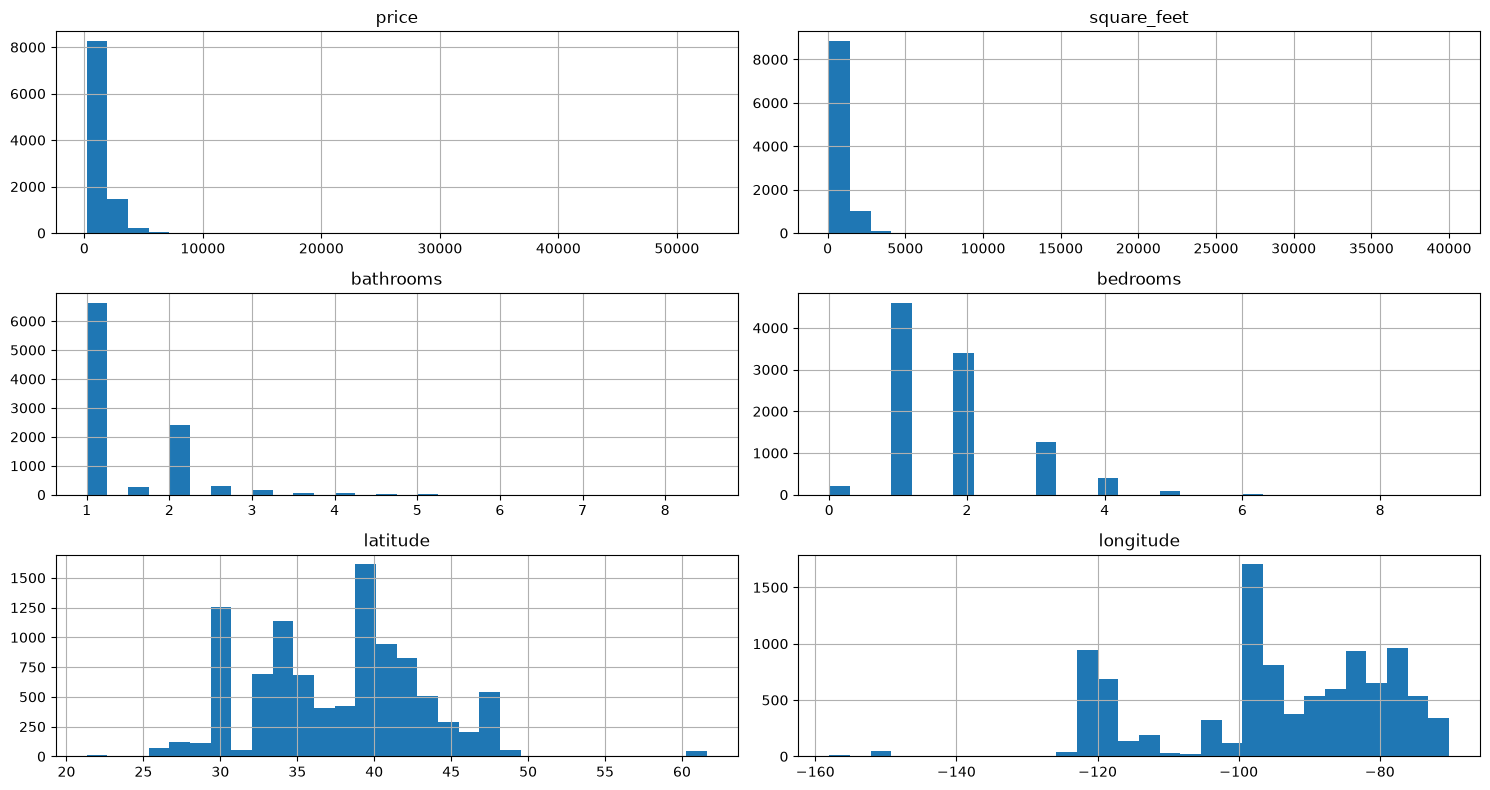

In [56]:
# Základné rozdelenia hlavných numerických premenných v RAW dátach.
# price a square_feet sú dôležité najmä na kontrolu pravostranného zošikmenia.
eda_numeric_cols = ['price', 'square_feet', 'bathrooms', 'bedrooms', 'latitude', 'longitude']

data[eda_numeric_cols].hist(figsize=(15, 8), bins=30)
plt.tight_layout()
plt.show()


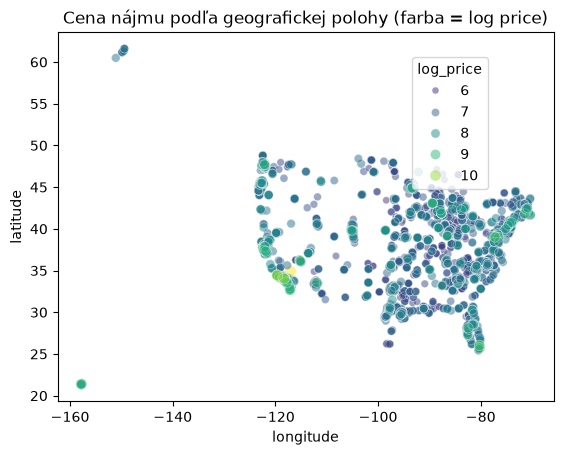

In [57]:
# Geografická EDA: farba a veľkosť bodu reprezentujú logaritmus ceny.
# Log používame iba pre čitateľnejšiu vizualizáciu – raw dáta týmto krokom nemeníme.
eda_map = data[['longitude', 'latitude', 'price']].dropna().copy()
eda_map = eda_map[eda_map['price'] > 0]
eda_map['log_price_eda'] = np.log(eda_map['price'])

sns.scatterplot(
    data=eda_map,
    x='longitude',
    y='latitude',
    size='log_price_eda',
    hue='log_price_eda',
    palette='viridis',
    alpha=0.5,
)
plt.legend(title='log_price', bbox_to_anchor=(0.7, 0.95), loc='upper left')
plt.title('Cena nájmu podľa geografickej polohy (farba = log price)');


In [58]:
# Chýbajúce hodnoty v pôvodných dátach.
# Samotnú imputáciu tu ešte NEROBÍME – prebehne až po train/test splite v pipeline,
# aby sa zabránilo data leakage z testovacej do tréningovej množiny.
data.isna().sum().sort_values(ascending=False).head(15)


pets_allowed    4163
amenities       3549
address         3327
cityname          77
state             77
bathrooms         34
latitude          10
longitude         10
bedrooms           7
category           0
title              0
body               0
id                 0
fee                0
price_type         0
dtype: int64

# Preprocessing dát

Po EDA upravujeme jednotlivé premenné do podoby vhodnej na modelovanie.

Dôležitý princíp: **transformácie, ktoré sa učia z dát (napr. imputácia, TargetEncoder alebo scaling), sa nesmú fitnúť na celom datasete pred train/test splitom.** Preto budú tieto kroky neskôr vo vnútri pipeline a budú sa učiť iba z tréningových dát.


## Úprava hodnôt jednotlivých stĺpcov

### `amenities`

`amenities` obsahuje zoznam vybavenia bytu oddelený čiarkami.

V tomto referenčnom riešení sa používa jednoduchá reprezentácia: **počet uvedených amenities** (`n_amenities`).

Výhoda:
- rýchle riešenie a takmer žiadne zvýšenie dimensionality.

Nevýhoda:
- model nerozlišuje, *aké* vybavenie byt má; napr. chladnička nemusí mať rovnaký vplyv na cenu ako bazén, tenisový kurt alebo vírivka.

Alternatívou by bolo vytvoriť pre každý typ vybavenia samostatnú 0/1 dummy (multi-hot) premennú.


In [59]:
# Jednoduchá reprezentácia amenities: počet položiek oddelených čiarkou.
# Missing hodnota sa tu interpretuje ako 0 uvedených amenities.
# Alternatíva: multi-hot/dummy stĺpce pre každý jednotlivý typ vybavenia.
data['amenities_list'] = data['amenities'].str.split(',')
data.loc[data['amenities_list'].isnull(), 'amenities_list'] = ''
data['n_amenities'] = data['amenities_list'].apply(len)


### `pets_allowed`

Podobne ako pri `amenities` prevádzame textový zoznam na **počet povolených typov zvierat**:

- nič uvedené → 0,
- pes alebo mačka → 1,
- oboje → 2.

Ide o jednoduchú numerickú reprezentáciu. Treba si však uvedomiť, že rozdiel medzi hodnotami 1 a 2 nemusí mať na cenu lineárny ekonomický význam.


In [60]:
# Prevod pets_allowed na počet povolených typov zvierat.
# Nič uvedené -> 0, jeden typ -> 1, oba typy -> 2.
data['pets_allowed_list'] = data['pets_allowed'].str.split(',')
data.loc[data['pets_allowed_list'].isnull(), 'pets_allowed_list'] = ''
data['pets_allowed_int'] = data['pets_allowed_list'].apply(len)


### `price_type` / `price`

Najprv pomocou `value_counts()` kontrolujeme, aké typy cien sa v dátach vyskytujú.

Týždenné a mesačné ceny musia byť prevedené na **rovnaké časové obdobie**, inak by niekoľko týždenných záznamov mohlo vyzerať ako extrémne lacné byty a výrazne zhoršiť chybu modelu aj $R^2$.

Referenčné riešenie prevádza hodnoty `Weekly` a `Monthly|Weekly` približne na mesačnú cenu násobením 4. Aj keď je takýchto záznamov málo, je vhodné pripraviť preprocessing tak, aby fungoval aj pri rozšírení datasetu.


In [61]:
data['price_type'].value_counts()

price_type
Monthly           9998
Weekly               1
Monthly|Weekly       1
Name: count, dtype: int64

In [62]:
data[['price_type', 'price']].sort_values('price_type', ascending=False).head(5)

,price_type,price
15,Weekly,1560
235,Monthly|Weekly,275
0,Monthly,790
1,Monthly,425
2,Monthly,1390


In [63]:
# Zjednotenie cien na približnú mesačnú bázu.
# V referenčnom riešení: Weekly / Monthly|Weekly -> price * 4.
# Dôvod: odlišná časová báza by vytvárala umelé cenové outliery.
data.loc[data['price_type'].isin(['Monthly|Weekly', 'Weekly']), 'price'] = data['price'] * 4


### `has_photo`

Premenná obsahuje hodnoty `Yes`, `No` a `Thumbnail`.

Riešenie ich prevádza na binárnu informáciu:

- `Yes` alebo `Thumbnail` → 1,
- inak → 0.

Myšlienkou je, že fotografia alebo aspoň náhľad môžu súvisieť s kvalitou prezentácie/marketingu inzerátu, a teda nepriamo aj s cenou.


In [64]:
data.has_photo.value_counts()

has_photo
Thumbnail    8907
Yes           909
No            184
Name: count, dtype: int64

In [65]:
# hodnoty 'Yes', 'Thumbnail' -> 1, inak 0
data['has_photo_int'] = 0
data.loc[data.has_photo.isin(['Yes', 'Thumbnail']), 'has_photo_int'] = 1

## Logaritmická transformácia

### Prečo logaritmovať `square_feet`

Rozloha bytov má typicky pravostranne zošikmené rozdelenie: väčšina bytov má relatívne bežnú veľkosť, ale existujú aj veľmi veľké nehnuteľnosti. Logaritmus stlačí extrémne hodnoty a rozdelenie býva symetrickejšie.

### Prečo je `price` zložitejšie

`price` je cieľová premenná. Modelovať `log_price` môže byť výhodné, ale výsledky treba interpretovať opatrne:

- model sa učí na `log_price`,
- ak chceme posúdiť chybu v skutočných dolároch, musíme predikcie previesť späť pomocou exponenciály,
- $R^2$ na `log_price` **nie je to isté** ako $R^2$ na pôvodnej cenovej škále.

K tomuto rozdielu sa vrátime pri vyhodnotení.


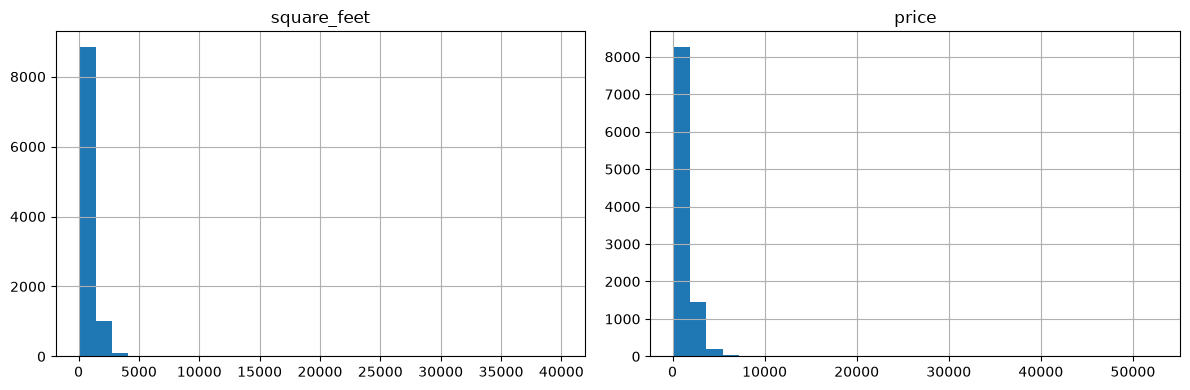

In [66]:
# zobrazenie stĺpcov so zošikmeným rozdelením
data[['square_feet', 'price']].hist(bins=30, figsize=(12, 4))
plt.tight_layout()
plt.show()

In [67]:
# Log transformácia plochy: stlačí pravý chvost veľkých bytov.
data['log_square_feet'] = np.log(data['square_feet'])


In [68]:
# Target modelujeme na logaritmickej škále.
# Pri business vyhodnotení treba predikcie previesť späť pomocou exp().
data['log_price'] = np.log(data['price'])


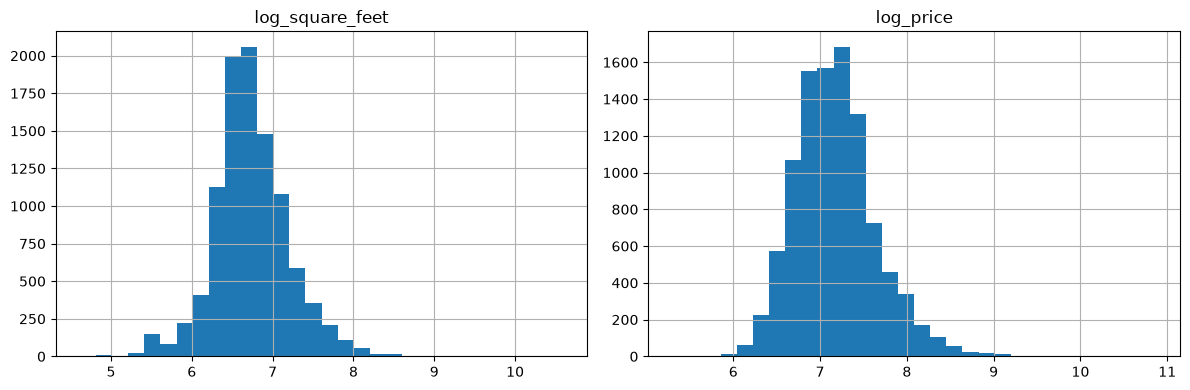

In [69]:
# po logaritmickej transformácii
data[['log_square_feet', 'log_price']].hist(bins=30, figsize=(12, 4), layout=(1, 2))

plt.tight_layout()
plt.show()

## Kontrola hodnôt v zostávajúcich stĺpcoch

`value_counts()` používame ako rýchlu kontrolu kategoriálnych premenných. Pomáha zistiť:

- takmer konštantné stĺpce,
- veľmi zriedkavé kategórie,
- duplicitu informácie,
- či má premenná zmysel pre model.

V tomto riešení napríklad:
- `currency` je konštantná → vyradíme,
- `fee` je konštantná → vyradíme,
- `category` je takmer konštantná → nepoužijeme,
- `price_display` duplikuje `price` → nepoužijeme,
- `source` ponecháme, pretože rôzne inzertné weby môžu mať odlišnú cenovú skladbu.


In [70]:
# (takmer) konštantné hodnoty
data.category.value_counts()

category
housing/rent/apartment     9996
housing/rent/home             2
housing/rent/short_term       2
Name: count, dtype: int64

In [71]:
# konštantné hodnoty
data.currency.value_counts()

currency
USD    10000
Name: count, dtype: int64

In [72]:
# konštantné hodnoty
data.fee.value_counts()

fee
No    10000
Name: count, dtype: int64

In [73]:
# price_display - rovnaká informácia ako price
data[['price', 'price_display']].head()

,price,price_display
0,790,$790
1,425,$425
2,1390,"$1,390"
3,925,$925
4,880,$880


In [74]:
data.source.value_counts()

source
RentLingo            6912
RentDigs.com         2764
ListedBuy             179
RealRentals            69
GoSection8             31
Listanza               23
RENTOCULAR             16
rentbits                2
Home Rentals            1
Real Estate Agent       1
RENTCafé                1
tenantcloud             1
Name: count, dtype: int64

## Zúženie dát na relevantné stĺpce

Vytvárame `data_narrow`: dataset obsahujúci iba premenné, ktoré chceme ďalej modelovať.

Cieľom je:
- odstrániť konštantné/takmer konštantné informácie,
- vyradiť duplicity a identifikátory,
- nepoužívať dlhé textové stĺpce, ktoré v tomto riešení ďalej nespracúvame,
- ponechať `source`, pretože zdroj inzerátu môže niesť cenovú informáciu.

Zároveň sa tým sprehľadní nasledujúca pipeline.


In [75]:
data.columns

Index(['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time', 'amenities_list',
       'n_amenities', 'pets_allowed_list', 'pets_allowed_int', 'has_photo_int',
       'log_square_feet', 'log_price'],
      dtype='str')

### Prehľad vyradených a ponechaných stĺpcov

**Vyradené pre (takmer) konštantné hodnoty:**
- `fee` – prakticky bez variability,
- `currency` – všetky ceny sú v USD,
- `category` – takmer všetky záznamy sú `housing`; niekoľko zriedkavých hodnôt by pridalo minimum informácie.

**Vyradené dlhé textové stĺpce:**
- `title`,
- `body`.

V tomto referenčnom riešení sa NLP nepoužíva, preto ich ďalej nespracúvame.

**Vyradené z ďalších dôvodov:**
- `id` – identifikátor, nie vlastnosť bytu,
- `price_display` – duplikuje cieľovú informáciu `price`,
- `time` – v tomto riešení sa nepoužíva ako časová feature.

**Ponechávame `source`:** zdrojový inzertný portál môže mať inú skladbu ponúk a cien, a preto môže mať predikčnú hodnotu.


In [76]:
# Modelovací dataset: iba vybrané relevantné premenné.
# Neobsahuje identifikátory, redundantný price_display ani dlhé texty.
data_narrow = data[[
    'log_price', 'bathrooms', 'bedrooms', 'log_square_feet',
    'cityname', 'state', 'latitude', 'longitude', 'source',
    'n_amenities', 'pets_allowed_int', 'has_photo_int'
]].copy()


## Analýza chýbajúcich hodnôt

V tejto fáze iba **identifikujeme** missing values a nuly.

Kľúčová zásada riešenia projektu:

> Imputáciu nevykonávame na celom datasete pred rozdelením na train/test.

Imputer sa neskôr fitne až vo vnútri pipeline na tréningovej časti. Inak by sa informácia z testovacej množiny mohla nepriamo premietnuť do imputovaných hodnôt (**data leakage**).

Nulová hodnota nemusí automaticky znamenať chybu – napríklad `bedrooms=0` môže predstavovať štúdio/garzónku. V produkčnom projekte by bolo vhodné overiť význam podozrivých nulových hodnôt voči zdrojovým webom.


In [77]:
# bude imputované
data_narrow.isna().sum()

log_price            0
bathrooms           34
bedrooms             7
log_square_feet      0
cityname            77
state               77
latitude            10
longitude           10
source               0
n_amenities          0
pets_allowed_int     0
has_photo_int        0
dtype: int64

In [78]:
# nulové hodnoty - nuly sú v uvedených stĺpcoch prípustné
# (napr. bedrooms=0 je prípustná hodnota pre štúdio/garzónku)
(data_narrow == 0).sum()

log_price              0
bathrooms              0
bedrooms             198
log_square_feet        0
cityname               0
state                  0
latitude               0
longitude              0
source                 0
n_amenities         3549
pets_allowed_int    4163
has_photo_int        184
dtype: int64

## Druhé mocniny latitude a longitude

Geografická EDA ukazuje, že cena nie je v priestore lineárna: niektoré oblasti (napr. časti pobrežia) majú systematicky vyššie ceny.

Preto pridávame:
- `latitude_sq = latitude²`
- `longitude_sq = longitude²`

Neskoršie `PolynomialFeatures` vytvoria ďalšie interakcie. Vďaka už existujúcim druhým mocninám možno v modeli zachytiť aj vyššie (3. a 4.) mocniny, a teda flexibilnejší zakrivený vzťah medzi polohou a cenou.

Tieto features by sa dali vytvoriť aj vo vnútri pipeline; tu sú vytvorené vopred najmä kvôli jednoduchšej práci s názvami stĺpcov.


In [79]:
data_narrow['latitude_sq'] = data_narrow['latitude'] ** 2
data_narrow['longitude_sq'] = data_narrow['longitude'] ** 2

# Modelovanie

## Pomocné funkcie

Používame dve pomocné funkcie:

- `search_grid_and_print_score()` – vykoná hyperparameter search a vypíše CV/train/test skóre,
- `print_scores()` – zjednotí porovnanie viacerých natrénovaných modelov.

> Poznámka: napriek názvu `search_grid...` implementácia používa **`RandomizedSearchCV`**, nie `GridSearchCV`. Prehľadáva teda náhodný počet kombinácií (`n_iter`), čo je rýchlejšie pri väčšom počte hyperparametrov.


In [80]:
def search_grid_and_print_score(estimator, param_distributions, X_train, X_test, y_train, y_test, cv=5, n_iter=20):
    """Natrénuje model pomocou RandomizedSearchCV vrátane hľadania hyperparametrov

    :param estimator: estimator alebo pipeline na natrénovanie
    :param param_distributions: priestor hyperparametrov
    :param X_train:
    :param X_test:
    :param y_train:
    :param y_test:
    :param cv: parameter cv pre RandomizedSearchCV
    :param n_iter: parameter n_iter pre RandomizedSearchCV
    """
    # objekt RandomizedSearchCV
    search = RandomizedSearchCV(estimator=estimator, param_distributions=param_distributions, n_iter=n_iter, scoring='r2', 
                                   cv=cv, random_state=42, n_jobs=-1, verbose=3)
    
    # natrénovanie modelu
    search.fit(X_train, y_train)

    # výsledky
    print("Najlepšie parametre:", search.best_params_)
    print("Najlepšie CV skóre:", np.round(search.best_score_, 3))
    print(f"Train skóre: {np.round(search.score(X_train, y_train), 3)}")
    print(f"Test skóre: {np.round(search.score(X_test, y_test), 3)}")

    return search

In [81]:
def print_scores(models, labels, X_train, X_test, y_train, y_test):
    """Vypočíta skóre všetkých modelov

    :param models: zoznam modelov
    :param labels: zoznam názvov modelov
    :param X_train:
    :param X_test:
    :param y_train:
    :param y_test:
    """
    scores_cv = []
    scores_train = []
    scores_test = []

    # prejdeme postupne všetky modely
    for model in models:
        scores_cv.append(np.round(model.best_score_, 3))
        scores_train.append(np.round(model.score(X_train, y_train), 3))
        scores_test.append(np.round(model.score(X_test, y_test), 3))

    results = pd.DataFrame({
        'CV': scores_cv,
        'Train': scores_train,
        'Test': scores_test        
    }, index=labels)

    return results

## Rozdelenie dát na train / test

Dáta rozdelíme na **75 % train / 25 % test** (`test_size=0.25`).

Testovacia množina má simulovať budúce, doteraz nevidené dáta. Preto sa na nej nesmie fitovať imputácia, encoding ani scaling – tieto kroky budú súčasťou pipeline a naučia sa iba z training časti.


In [82]:
X = data_narrow.copy().drop(columns='log_price')
y = data_narrow.log_price

In [83]:
# 75 % train / 25 % test.
# Všetky transformácie učené z dát (encoding, imputácia, scaling) budú až v pipeline.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


## Pipeline na transformáciu dát

Transformácie sú zabalené do pipeline, aby sa všetky kroky učili iba z tréningových dát (a pri cross-validácii vždy iba z príslušného training foldu).

Poradie:

1. **Encoding kategórií**
   - `cityname`, `state` a `source` dostávajú Target Encoding aj obmedzený One-Hot Encoding.
   - `max_categories` obmedzuje počet OHE stĺpcov; menej časté hodnoty sa zlúčia do `infrequent`.
   - `max_categories` je tiež hyperparameter a možno ho optimalizovať.

2. **KNN imputácia**
   - prebieha až po encodingu, pretože KNNImputer pracuje s numerickými hodnotami,
   - počet susedov aj spôsob váženia sú súčasťou hyperparameter search.

3. **Polynomial / interaction features**
   - vytvárame iba pre vybrané premenné, aby sme nekontrolovane nezvýšili dimensionalitu.

4. **RobustScaler**
   - obmedzuje vplyv extrémnych hodnôt,
   - scaling je obzvlášť dôležitý pre regularizované lineárne modely, ako je LASSO.

`verbose_feature_names_out=False` skracuje názvy transformovaných stĺpcov a uľahčuje ich ďalšie použitie.


In [84]:
X.columns

Index(['bathrooms', 'bedrooms', 'log_square_feet', 'cityname', 'state',
       'latitude', 'longitude', 'source', 'n_amenities', 'pets_allowed_int',
       'has_photo_int', 'latitude_sq', 'longitude_sq'],
      dtype='str')

In [85]:
# NOVÉ: odkazovanie na transformované stĺpce je zjednodušené pomocou verbose_feature_names_out=False; k názvu stĺpca sa nepridáva prefix transformátora.
# Rovnaký výsledok by sa dal dosiahnuť aj bez tohto parametra, ale museli by sme zistiť presný názov transformovaného stĺpca.
cols_ohe = ['cityname', 'state']
cols_interactions = ['n_amenities', 'bathrooms', 'bedrooms', 'pets_allowed_int', 'log_square_feet', 'cityname', 'state', 'source', 'latitude', 'longitude', 'latitude_sq', 'longitude_sq']
cols_nan = ['bathrooms','bedrooms','latitude', 'latitude_sq', 'longitude', 'longitude_sq', 'cityname', 'state']

In [86]:
# Encoding kategoriálnych premenných.
#
# cityname + state:
#   - TargetEncoder zachytí vzťah k targetu,
#   - OHE zachová informáciu o najčastejších kategóriách.
#
# source:
#   - rovnaký princíp, ale menej OHE kategórií.
#
# max_categories obmedzuje dimensionalitu a menej časté hodnoty zlučuje do 'infrequent'.
# Hodnota max_categories je sama osebe hyperparameter a neskôr ju ladíme.
encoder = make_column_transformer(
    (TargetEncoder(target_type='continuous'), cols_ohe),
    (OneHotEncoder(max_categories=5, handle_unknown='infrequent_if_exist', sparse_output=False), cols_ohe),

    (TargetEncoder(target_type='continuous'), ['source']),
    (OneHotEncoder(max_categories=3, handle_unknown='infrequent_if_exist', sparse_output=False), ['source']),

    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')


In [87]:
# KNN imputácia missing hodnôt.
# Prebieha až po train/test splite a vo vnútri pipeline -> bez leakage z testu.
# n_neighbors a weights budeme ladiť ako hyperparametre.
imputer = make_column_transformer(
    (KNNImputer(n_neighbors=5, weights='distance', add_indicator=False), cols_nan),
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')


In [88]:
# Interakcie iba medzi vybranými premennými.
# interaction_only=True nevytvára priamo všetky druhé mocniny,
# ale keďže latitude_sq / longitude_sq už existujú, vzniknú aj kombinácie
# zodpovedajúce vyšším mocninám a zložitejším geografickým vzťahom.
interactions = make_column_transformer(
    (PolynomialFeatures(degree=2, interaction_only=True, include_bias=False), cols_interactions),
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')


In [89]:
# Kompletná transformačná pipeline.
# Fit každého kroku sa pri CV vykoná iba na training folde.
# RobustScaler je odolnejší voči outlierom a je dôležitý najmä pre LASSO.
pipe_transform = make_pipeline(
    encoder,
    imputer,
    interactions,
    RobustScaler().set_output(transform='pandas')
)


In [90]:
# Iba diagnostická ukážka výsledku preprocessing pipeline.
# Fitujeme ju tu na X_train, nie na celom datasete.
transformed_data = pipe_transform.fit_transform(X_train, y_train)


In [91]:
# zobrazenie transformovaných dát
transformed_data.head()

# Hodnoty môžu byť záporné, pretože RobustScaler centruje transformované
# premenné okolo ich mediánu. Záporné hodnoty bedrooms/bathrooms preto
# NEPREDSTAVUJÚ záporný fyzický počet izieb; ide o škálované hodnoty
# používané modelom.


,n_amenities,bathrooms,bedrooms,pets_allowed_int,log_square_feet,cityname,state,source,latitude,longitude,...,cityname_infrequent_sklearn,state_CA,state_NC,state_TX,state_WA,state_infrequent_sklearn,source_RentDigs.com,source_RentLingo,source_infrequent_sklearn,has_photo_int
4901,0.0,0.0,-1.0,0.0,-0.011843,0.441652,-0.047070,-0.079342,0.574750,0.224540,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4375,1.4,0.0,-1.0,-0.5,-0.109342,0.214195,0.238302,0.037845,0.817591,0.014863,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6698,0.2,0.0,0.0,-1.0,0.381650,-1.294016,-0.522009,0.975708,0.388740,0.519453,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0
9805,-0.4,2.5,1.0,-1.0,2.143324,-0.712550,0.449158,0.037845,-1.100968,0.624717,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1101,0.6,0.0,-1.0,-1.0,-0.845355,-0.364050,-0.350595,-0.079342,-1.100115,-0.205593,...,-1.0,0.0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0


In [92]:
# transformed_data.columns

## Model 1 – Random Forest

Random Forest kombinuje veľa rozhodovacích stromov a ich predikcie agreguje. Prirodzene dokáže zachytiť nelinearity a interakcie medzi features.

Hyperparameter search tu neladí iba samotný Random Forest, ale aj parametre predchádzajúcej transformačnej pipeline (napr. `max_categories` alebo nastavenie KNN imputácie). To je dôležité: **hyperparametrom môže byť prakticky ktorýkoľvek parameter v pipeline.**

Po natrénovaní sa objekt uloží cez `pickle`, aby nebolo potrebné náročný search spúšťať pri každom otvorení notebooku.


In [93]:
# celková modelovacia pipeline
pipe_model_rf = make_pipeline(
    pipe_transform,
    RandomForestRegressor(random_state=42))

In [94]:
# pipe_model_rf.get_params()

### Čo sa ladí pri Random Foreste

Search zahŕňa **modelové hyperparametre** (`max_depth`, `n_estimators`, `max_features`, ...) aj **preprocessing hyperparametre** (`max_categories`, `n_neighbors`, `weights`).

Je to jedna z hlavných výhod pipeline: celý preprocessing + model možno optimalizovať ako jeden celok.


In [95]:
param_grid_rf = {

    # Maximum number of categories kept by OneHotEncoder.
    # Less frequent categories are grouped into the "infrequent" category.
    # Higher values preserve more categorical detail but also increase dimensionality.
    'pipeline__columntransformer-1__onehotencoder-1__max_categories': [3, 5, 8],


    # Počet najbližších pozorovaní, ktoré KNNImputer používa
    # na odhad chýbajúcich hodnôt.
    # Menšie hodnoty používajú lokálnejšiu informáciu,
    # vyššie hodnoty vedú k hladším imputáciám.
    'pipeline__columntransformer-2__knnimputer__n_neighbors': [5, 10, 20],


    # Ako susedné pozorovania prispievajú ku KNN imputácii:
    # - 'uniform': všetci vybraní susedia majú rovnakú váhu
    # - 'distance': bližší susedia dostávajú vyššiu váhu
    'pipeline__columntransformer-2__knnimputer__weights': ['distance', 'uniform'],


    # Podiel dostupných features uvažovaných pri hľadaní
    # najlepšieho splitu v každom strome.
    # Napríklad 0.5 znamená, že pri každom splite sa uvažuje
    # približne 50 % features.
    #
    # Nižšie hodnoty zvyšujú náhodnosť medzi stromami a môžu znižovať overfitting.
    'randomforestregressor__max_features': [0.5, 0.6, 0.7],


    # Minimálny počet pozorovaní, ktoré musia zostať
    # v koncovom leaf node.
    #
    # Vyššie hodnoty robia stromy konzervatívnejšie / hladšie
    # a môžu znižovať overfitting.
    'randomforestregressor__min_samples_leaf': [1, 5, 8],


    # Maximálna hĺbka každého rozhodovacieho stromu.
    #
    # None = no explicit depth limit;
    # the tree grows until another stopping condition is reached.
    #
    # Smaller values create simpler trees and stronger regularization.
    'randomforestregressor__max_depth': [None, 5, 10, 18],


    # Minimum number of observations required in a node
    # before the algorithm is allowed to split it.
    #
    # Higher values prevent splitting very small groups
    # and can therefore reduce overfitting.
    'randomforestregressor__min_samples_split': [2, 5, 9],


    # Number of decision trees in the Random Forest.
    #
    # More trees usually make the prediction more stable,
    # but also increase training and prediction time.
    'randomforestregressor__n_estimators': [80, 110, 140]
}

### Uloženie natrénovaných modelov (`pickle`)

Hyperparameter search môže trvať dlho. Preto sa natrénovaný objekt uloží pomocou `pickle.dump()`.

- pri `train_flag=True` sa model natrénuje a uloží,
- pri `train_flag=False` sa načíta cez `pickle.load()`.

Takto možno notebook znovu otvoriť a pokračovať vo vyhodnotení bez opakovaného trénovania.


In [96]:
if train_flag:
    # natrénovanie modelu
    model_rf = search_grid_and_print_score(pipe_model_rf, param_grid_rf, X_train, X_test, y_train, y_test, n_iter=30)

    # uloženie modelu
    with open(r'models\model_rf.pkl', 'wb') as f:
        pickle.dump(model_rf, f)
else:
    # načítanie uloženého modelu
    with open(r'models\model_rf.pkl', 'rb') as f:
        model_rf = pickle.load(f)

## Model 2 – XGBRegressor

XGBoost je gradient boosting: stromy vznikajú postupne a každý ďalší sa snaží zlepšiť chyby predchádzajúcich stromov.

Rovnako ako pri Random Foreste optimalizujeme súčasne:
- preprocessing,
- počet stromov,
- learning rate,
- hĺbku stromov,
- subsampling,
- výber features.

Model sa po trénovaní opäť uloží pomocou `pickle`.


In [97]:
# celková modelovacia pipeline
pipe_model_xgb = make_pipeline(
    pipe_transform,
    XGBRegressor(random_state=42))

In [98]:
# pipe_model_xgb.get_params()

### Čo sa ladí pri XGBooste

Okrem preprocessing parametrov ladíme napríklad:

- `learning_rate` – veľkosť kroku každého boosting stromu,
- `n_estimators` – počet stromov,
- `max_depth` – komplexnosť stromov,
- `subsample` – podiel riadkov použitých pre jednotlivé stromy,
- `colsample_bytree` – podiel features použitých pre strom.

Cieľom nie je iba maximalizovať training score, ale nájsť kombináciu s najlepším cross-validačným $R^2$.


In [99]:
param_grid_xgb = {
    'pipeline__columntransformer-1__onehotencoder-1__max_categories': [3, 5, 8],
    'pipeline__columntransformer-2__knnimputer__n_neighbors': [5, 10, 20],
    'pipeline__columntransformer-2__knnimputer__weights': ['distance', 'uniform'],
    'xgbregressor__learning_rate': [0.05, 0.1, 0.2], 
    'xgbregressor__colsample_bytree':  [0.3,0.5,0.7],
    'xgbregressor__max_depth': [None, 5, 10, 15],
    'xgbregressor__subsample': [0.3, 0.5, 0.7],
    'xgbregressor__n_estimators': [100, 150, 200]
}

In [100]:
if train_flag:
    # natrénovanie modelu
    model_xgb = search_grid_and_print_score(pipe_model_xgb, param_grid_xgb, X_train, X_test, y_train, y_test, n_iter=30)

    # uloženie modelu
    with open(r'models\model_xgb.pkl', 'wb') as f:
        pickle.dump(model_xgb, f)
else:
    # načítanie uloženého modelu
    with open(r'models\model_xgb.pkl', 'rb') as f:
        model_xgb = pickle.load(f)

## Model 3 – LASSO (referenčný model)

LASSO je lineárny regresný model s **L1 regularizáciou**. Slúži tu ako jednoduchší referenčný model voči stromovým ensemble metódam.

L1 regularizácia môže niektoré koeficienty stiahnuť až na nulu, takže zároveň funguje ako forma výberu features. Keďže penalizácia závisí od veľkosti koeficientov, je dôležité mať vstupné premenné vhodne preškálované – tu cez `RobustScaler`.

Tuning LASSA je výrazne rýchlejší, pretože má menej modelových hyperparametrov.


In [101]:
# celková modelovacia pipeline
pipe_model_lasso = make_pipeline(
    pipe_transform,
    Lasso()
)

In [102]:
#pipe_model_lasso.get_params()


### Čo sa ladí pri LASSE

LASSO má menej modelových hyperparametrov; hlavným je `alpha`, teda sila L1 regularizácie.

Zároveň sa stále ladí preprocessing (napr. počet OHE kategórií a nastavenie KNN imputácie), takže aj jednoduchý model dostáva férovo optimalizovaný vstup.


In [103]:
param_grid_lasso = {
    'pipeline__columntransformer-1__onehotencoder-1__max_categories': [3, 5, 8],
    'pipeline__columntransformer-2__knnimputer__n_neighbors': [5, 10, 20],
    'pipeline__columntransformer-2__knnimputer__weights': ['distance', 'uniform'],
    'lasso__alpha': [0.005, 0.01, 0.05, 0.1]
}

In [104]:
if train_flag:
    # trénovanie modelu
    model_lasso = search_grid_and_print_score(pipe_model_lasso, param_grid_lasso, X_train, X_test, y_train, y_test, n_iter=30)

    # uloženie modelu
    with open(r'models\model_lasso.pkl', 'wb') as f:
        pickle.dump(model_lasso, f)
else:
    # načítanie uloženého modelu
    with open(r'models\model_lasso.pkl', 'rb') as f:
        model_lasso = pickle.load(f)


## Model 4 – Ridge (referenčný model)

LASSO je lineárny regresný model s **L1 regularizáciou**. Slúži ako jednoduchší referenčný model voči stromovým ensemble metódam.

L1 regularizácia môže niektoré koeficienty zmenšiť až presne na nulu, takže zároveň funguje ako forma výberu premenných. Keďže penalizácia závisí od veľkosti koeficientov, vstupné premenné by mali byť vhodne škálované – tu to zabezpečuje `RobustScaler`.

Ladenie LASSO je výrazne rýchlejšie, pretože má menej hyperparametrov špecifických pre model.

Ridge je lineárny regresný model s **L2 regularizáciou**. Rovnako ako LASSO slúži ako jednoduchší referenčný model voči stromovým ensemble metódam.

**L2 regularizácia penalizuje veľké hodnoty koeficientov a zmenšuje ich smerom k nule, ale na rozdiel od LASSO ich zvyčajne nezníži presne na nulu. Ridge preto typicky ponechá všetky features v modeli a zníži ich individuálny vplyv.**

Ridge môže byť obzvlášť užitočný, keď sú viaceré prediktory korelované, pretože model môže rozdeliť ich príspevok medzi viac súvisiacich premenných namiesto výberu iba niektorých z nich. Rovnako ako pri LASSO je dôležité vhodné škálovanie vstupov, pretože penalizácia závisí od veľkosti koeficientov. Tu škálovanie zabezpečuje `RobustScaler`.

Ridge má tiež relatívne málo hyperparametrov špecifických pre model. Hlavným parametrom je `alpha`, ktorý riadi silu L2 regularizácie, takže ladenie hyperparametrov je výrazne rýchlejšie než pri stromových ensemble modeloch.


In [105]:
# kompletná modelovacia pipeline
pipe_model_ridge = make_pipeline(
    pipe_transform,
    Ridge()
)


In [106]:
#pipe_model_ridge.get_params()


### Čo sa ladí pri Ridge

Ridge má menej hyperparametrov špecifických pre model; hlavným je `alpha`, ktorý riadi silu **L2 regularizácie**.

Vyššie `alpha` znamená silnejšiu regularizáciu a výraznejšie zmenšovanie koeficientov smerom k nule, zatiaľ čo nižšie `alpha` umožňuje modelu voľnejšie sa prispôsobiť tréningovým dátam.

Súčasne sa stále ladí aj preprocessing – napríklad počet OHE kategórií a nastavenie KNN imputácie – takže Ridge sa vyhodnocuje v rovnakom optimalizovanom preprocessingovom rámci ako ostatné modely.


In [107]:
param_grid_ridge = {
    'pipeline__columntransformer-1__onehotencoder-1__max_categories': [3, 5, 8],
    'pipeline__columntransformer-2__knnimputer__n_neighbors': [5, 10, 20],
    'pipeline__columntransformer-2__knnimputer__weights': ['distance', 'uniform'],
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}


In [108]:
if train_flag:
    # trénovanie modelu
    model_ridge = search_grid_and_print_score(pipe_model_ridge, param_grid_ridge, X_train, X_test, y_train, y_test, n_iter=30)

    # uloženie modelu
    with open(r'models\model_ridge.pkl', 'wb') as f:
        pickle.dump(model_ridge, f)
else:
    # načítanie uloženého modelu
    with open(r'models\model_ridge.pkl', 'rb') as f:
        model_ridge = pickle.load(f)


V tomto projekte je porovnanie obzvlášť relevantné, pretože preprocessing pipeline vytvára veľké množstvo transformovaných a potenciálne korelovaných features vrátane one-hot encoded premenných, interakčných členov a geografických features. Porovnanie Ridge a LASSO preto pomáha posúdiť, či zachovanie korelovanej informácie zlepšuje výkon lineárneho benchmarku.


# Vyhodnotenie

Najprv porovnávame modely na targete `log_price`, pretože práve na ňom boli trénované.

Potom najlepší model vyhodnotíme aj po prevode predikcií späť na **skutočnú cenu**. To je zásadné: dobré $R^2$ na logaritmovanej cene nemusí znamenať rovnako dobré $R^2$ v dolároch.


## Porovnanie modelov

Porovnávame:

- najlepšie cross-validačné skóre z hyperparameter search,
- skóre na celej training množine,
- skóre na testovacej množine.

Veľký rozdiel medzi train a test skóre môže naznačovať overfitting. Pre výber hyperparametrov je najdôležitejšia cross-validation; test slúži ako finálna kontrola generalizácie.


In [109]:
models = [
    model_rf,
    model_xgb,
    model_lasso,
    model_ridge
]


In [110]:
labels = [
    'random forest',
    'xgb',
    'lasso',
    'ridge'
]


In [111]:
print_scores(models, labels, X_train, X_test, y_train, y_test)

,CV,Train,Test
random forest,0.752,0.885,0.758
xgb,0.766,0.858,0.767
lasso,0.679,0.734,0.680
ridge,0.696,0.747,0.693


## ShuffleSplit cross-validácia najlepšieho modelu

Pre najlepší model (XGBoost) robíme ešte dodatočnú kontrolu pomocou `ShuffleSplit`.

Na rozdiel od klasického K-Foldu vytvára `ShuffleSplit` opakovane náhodné train/validation rozdelenia. Priemer a smerodajná odchýlka skóre nám dávajú predstavu o stabilite výkonu modelu pri rôznych rozdeleniach dát.


In [112]:
from sklearn.model_selection import ShuffleSplit, cross_val_score

In [113]:
# získa najlepší model
best_model = model_xgb.best_estimator_

In [114]:
# získanie CV skóre
cv_shs = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
scores_shs = cross_val_score(best_model, X_train, y_train, cv=cv_shs)

In [115]:
scores_shs

array([0.74546073, 0.76445965, 0.74586669, 0.7512815 , 0.74492443])

In [116]:
print(f'{scores_shs.mean():.3f} with a standard deviation of {scores_shs.std():.3f}')

0.750 with a standard deviation of 0.007


In [117]:
# best_model je najlepší estimator z XGBoost searchu.
print(f"Test skóre XGBoost: {np.round(best_model.score(X_test, y_test), 3)}")


Test skóre XGBoost: 0.767


## Permutačná dôležitosť premenných

Aby sme lepšie pochopili, ktoré vstupné premenné najviac prispievajú k prediktívnemu výkonu zvolenej XGBoost pipeline, použijeme **permutation importance**.

Princíp je jednoduchý:

1. vyhodnotíme fitnutý model na nezmenenej testovacej vzorke,
2. náhodne premiešame jednu feature a ostatné necháme nezmenené,
3. znovu vypočítame skóre modelu,
4. zmeriame, o koľko R² klesne,
5. premiešanie viackrát zopakujeme a výsledok spriemerujeme.

Ak premiešanie feature spôsobí veľký pokles R², model sa silno spolieha na informáciu obsiahnutú v tejto premennej. Ak sa skóre zmení iba mierne, feature prispieva k prediktívnemu výkonu menej.

Permutation importance sa počíta na **`X_test` a `y_test`**, takže hodnoty importance opisujú závislosť modelu od premenných pri predikcii predtým nevidených pozorovaní.

> **Dôležité:** permutation importance meria prediktívnu dôležitosť, nie kauzalitu. Veľmi dôležitá premenná nemusí byť príčinou zvýšenia alebo zníženia nájomného.


In [118]:
# Výpočet permutation importance na odloženej testovacej vzorke.
# Každá feature sa premieša 10-krát a priemerný pokles R²
# ukazuje, ako silno sa fitnutý model na danú feature spolieha.
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


In [119]:
# Uloženie priemernej importance a jej smerodajnej odchýlky pre každú
# pôvodnú vstupnú feature a zoradenie od najdôležitejšej po najmenej dôležitú.
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
})

feature_importance = (feature_importance.sort_values("importance", ascending=False))

feature_importance


,feature,importance,std
2,log_square_feet,0.330337,0.011967
4,state,0.245732,0.006413
3,cityname,0.152923,0.004132
0,bathrooms,0.042295,0.002810
6,longitude,0.036078,0.002684
12,longitude_sq,0.032815,0.002801
1,bedrooms,0.029325,0.001260
5,latitude,0.025808,0.002241
11,latitude_sq,0.023116,0.001650
8,n_amenities,0.008316,0.000913


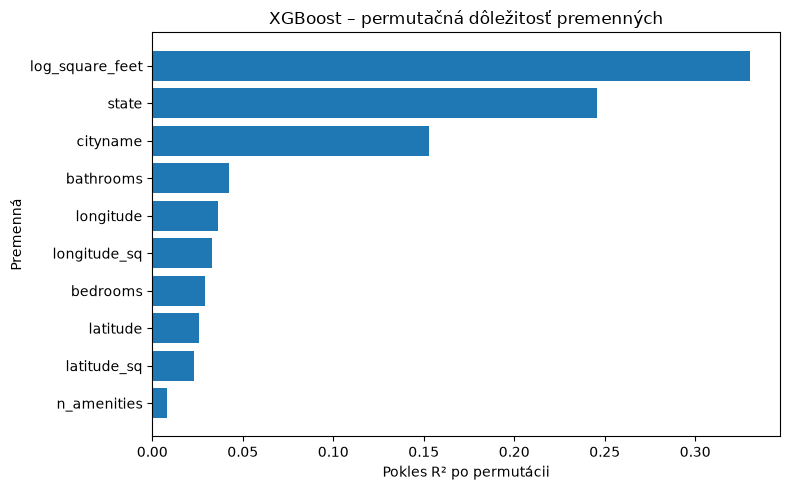

In [120]:
top_features = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(8, 5))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Pokles R² po permutácii")
plt.ylabel("Premenná")
plt.title("XGBoost – permutačná dôležitosť premenných")

plt.tight_layout()
plt.show()


### Interpretácia výsledkov feature importance

Výsledky ukazujú, že **veľkosť bytu a geografická poloha sú dominantnými zdrojmi prediktívnej informácie** pre model XGBoost.

- **`log_square_feet`** je najdôležitejšia feature. Jej premiešanie znižuje R² v priemere približne o **0.330**, čo naznačuje, že veľkosť bytu je najdôležitejším jednotlivým vstupom pre predikciu.
- **`state`** je druhá najdôležitejšia feature s priemerným poklesom R² približne **0.246**.
- **`cityname`** nasleduje s importance približne **0.153**. Spolu `state` a `cityname` ukazujú, že geografická poloha obsahuje veľké množstvo informácie o cenách prenájmu.
- **`bathrooms`**, **`bedrooms`**, **`latitude`**, **`longitude`** a ich druhé mocniny pridávajú ďalšiu prediktívnu informáciu, ale ich individuálny vplyv je podstatne menší.
- **`n_amenities`**, **`source`** a **`pets_allowed_int`** majú relatívne nízku permutation importance.
- **`has_photo_int`** má v tomto modeli takmer nulový vplyv na testovacie R².

Napríklad importance **0.330** pre `log_square_feet` znamená, že náhodné zničenie informácie v tejto feature znižuje R² modelu približne o **0.33 bodu v priemere**. **Neznamená** to, že táto feature sama vysvetľuje 33 % nájomného.

Tieto hodnoty treba interpretovať opatrne. Keď sú prediktory korelované – napríklad `state`, `cityname`, `latitude` a `longitude` – ich informácia sa môže prekrývať. Permutation importance preto môže rozdeliť prediktívnu dôležitosť medzi viac súvisiacich premenných.

Celkovo analýza naznačuje, že model sa primárne spolieha na **veľkosť nehnuteľnosti a geografickú polohu**, zatiaľ čo metadáta ponuky, ako dostupnosť fotografie alebo zdroj, prispievajú k prediktívnemu výkonu výrazne menej.


## Vyhodnotenie chyby na `price` namiesto `log_price`

Model predikuje `log_price`, ale z business pohľadu nás zvyčajne zaujíma skutočné nájomné.

Preto:
1. predikujeme `log_price`,
2. pomocou `np.exp()` prevedieme target aj predikciu späť do dolárov,
3. znovu vypočítame $R^2$ na pôvodnej cenovej škále.

V riešení vidíme výrazný pokles $R^2$ po návrate na pôvodnú cenu. Hlavnou príčinou sú veľmi drahé outliery: keďže $R^2$ vychádza zo štvorcových chýb, niekoľko extrémnych omylov môže metriku výrazne zhoršiť.

Následne sa na diagnostické účely skúma výsledok bez horných 2 % cien (98. percentil). **Nie je to automaticky správny produkčný postup** – či môžeme extrémny segment vyradiť, je business rozhodnutie a pri reportovaní výsledkov to musí byť explicitne uvedené.


In [121]:
y_pred_test = best_model.predict(X_test)

In [122]:
# R² skóre na testovacej vzorke pre log_price
r2_score(y_test, y_pred_test)


0.7667955826919824

In [123]:
# R² na pôvodnej cenovej škále.
# np.exp() je inverzná transformácia log() použitej pri tvorbe log_price.
r2_score(np.exp(y_test), np.exp(y_pred_test))


0.3662207785078909

In [124]:
# Diagnostika outlierov: hranica horných 2 % targetu.
# Pozor: y_test je log_price, takže percentil je tu definovaný na log škále.
# Vyradenie týchto pozorovaní je analytický experiment, nie automatické pravidlo.
pct98 = np.percentile(y_test, 98)
pct98


np.float64(8.292798858200374)

In [125]:
# R² na pôvodnej price škále po vyradení horných 2 % cien.
# Tento výsledok vždy reportujeme spolu s informáciou, že extrémy boli odfiltrované.
hi_prices_mask = y_test > pct98
r2_score(
    np.exp(y_test[~hi_prices_mask]),
    np.exp(y_pred_test[~hi_prices_mask])
)


0.738699490014415

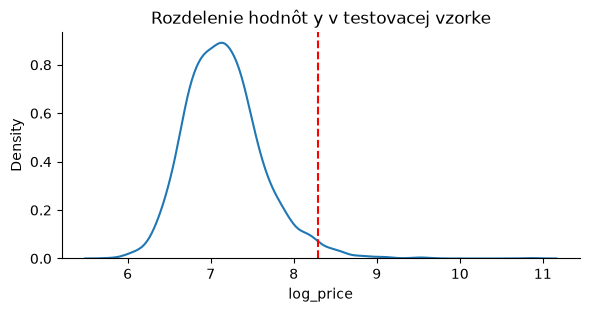

In [129]:
sns.displot(x=y_test, kind='kde', height=3, aspect=2, bw_adjust=1)
plt.axvline(x=pct98, linestyle='--', color='red')
plt.title('Rozdelenie hodnôt y v testovacej vzorke');

plt.savefig('figures/log_price_distribution_SK.png', dpi=150, bbox_inches='tight')

# Rovnaký efekt je viditeľný aj v rozdelení log_price:
# pravý chvost rozdelenia je časť, ktorá sa v diagnostickom experimente vylúči.


In [130]:
r2_score(
    np.exp(y_test[~hi_prices_mask]),
    np.exp(y_pred_test[~hi_prices_mask]))

0.738699490014415

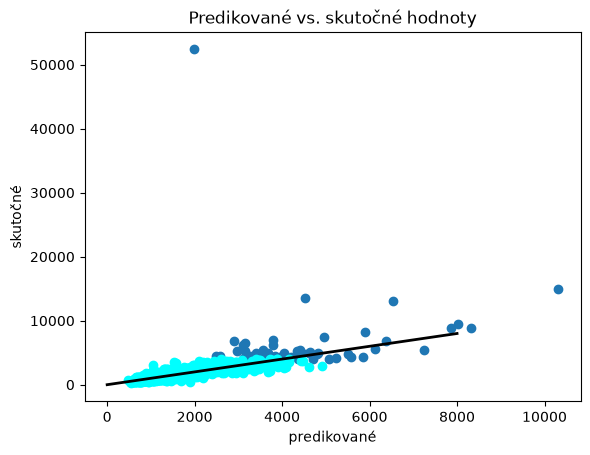

In [131]:
plt.scatter(np.exp(y_pred_test[hi_prices_mask]), np.exp(y_test[hi_prices_mask]))
plt.scatter(np.exp(y_pred_test[~hi_prices_mask]), np.exp(y_test[~hi_prices_mask]), c='cyan')
plt.plot([0, 8000], [0, 8000], color = 'black', linewidth = 2)
plt.xlabel('predikované')
plt.ylabel('skutočné')
plt.title('Predikované vs. skutočné hodnoty');

plt.savefig('figures/predicted_vs_actual_SK.png', dpi=150, bbox_inches='tight')

# Rovnaký efekt je zobrazený aj v grafe predicted-vs-actual.
# Horizontálna os obsahuje predikované hodnoty a vertikálna os skutočné hodnoty.
# Jedno obzvlášť extrémne pozorovanie je jasne viditeľné.
#
# R² priamo súvisí s predikčnými chybami a tieto chyby vstupujú do výpočtu
# v druhej mocnine. Preto aj jeden veľmi veľký omyl môže neúmerne prispieť
# k celkovej chybe.
#
# Toto extrémne pozorovanie spolu s ďalšími prípadmi vysokých cien vysvetľuje,
# prečo je R² na netransformovanej cene podstatne nižšie.
# Diagnostický experiment vylučuje horné 2 % cieľových hodnôt (zobrazené modrou).
# Po odstránení extrémnych prípadov sa R² modelu výrazne zlepší.
# Stále však ide o diagnostický experiment, nie automatické produkčné pravidlo.
